## Plot Abil Output

In [1]:
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr
import os
import sys
from yaml import load, Loader
from matplotlib import cm
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

In [2]:
with open('regressor.yml', 'r') as f:
    model_config = load(f, Loader=Loader)

run_name = 'pp_na/'
file = '2026-04-28_mean'
ds = xr.open_dataset(model_config['local_root'] + model_config['path_out'] + run_name + 'posts/' + file + ".nc")

### Create of map of surface pimary production in April

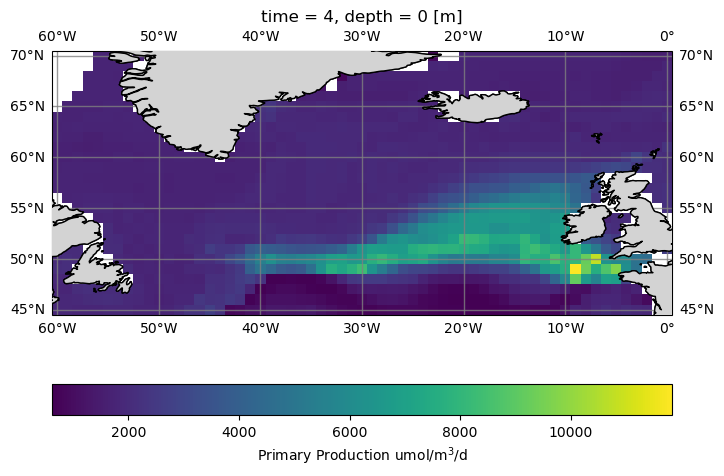

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)
p = ds['Primary_Production'].sel(
    depth=0, 
    time=4
    ).plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Primary Production µmol/m$^3$/d")

### Create map of depth integrated annual production

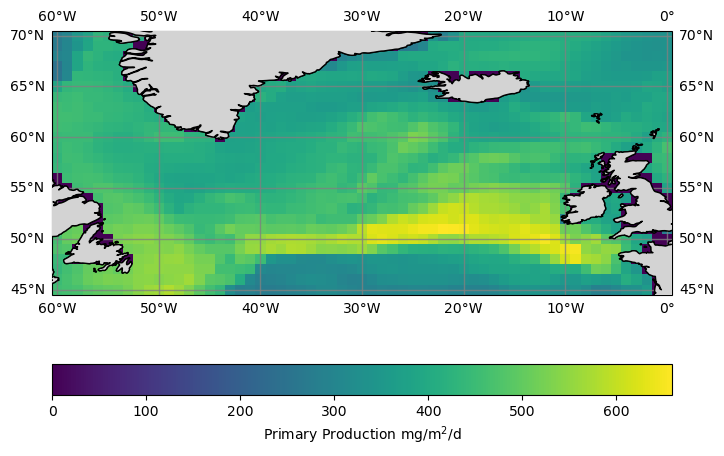

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)

conversion_factor = 12.01e-3 # µmol to mg of C (C atomic weight)
depth_width = 5
depth_integrated_pp = ds['Primary_Production'].sum(dim=["depth"]).mean(dim="time") * depth_width * conversion_factor

p = depth_integrated_pp.plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Primary Production mg/m$^2$/d")

### Plot timeseries of production at a specific location
(add confidence intervals)

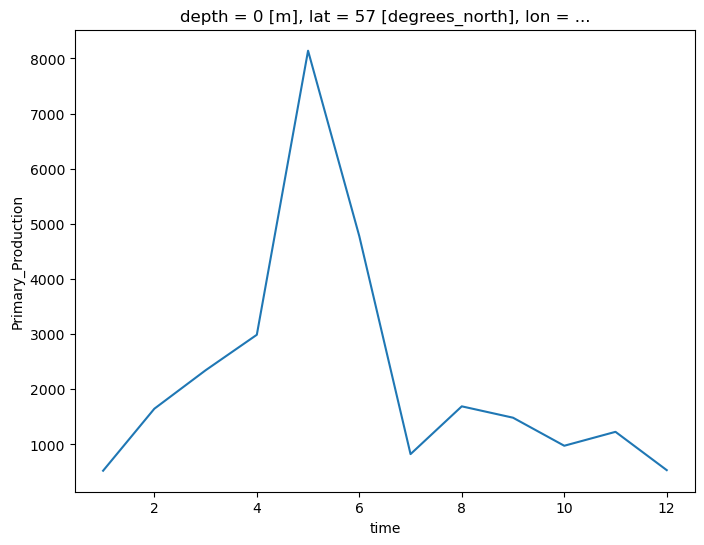

In [7]:
fig = plt.figure(figsize=(8, 6))

p = ds['Primary_Production'].sel(
    lat=57, 
    lon=-20,
    depth=0
    ).plot()